# Week 9: Change Detection & Validation — ARIA v6.0
## 第九週：變化偵測與驗證 — ARIA v6.0（經過驗證的稽核員）

**Course**: 遙測與空間資訊之分析與應用 | Remote Sensing Analysis & Applications
**Institution**: National Taiwan University (NTU)
**Instructor**: Prof. Su Wen-Ray (蘇文瑄教授)
**Case Study**: Matai'an Barrier Lake (Typhoon Colo)

### Lab Rhythm / 實驗時間分配
| Lab | Topic | Duration | 主題 |
|-----|-------|----------|------|
| **Lab 1** | Difference Mapping (NDVI/NDWI) | 35 min | 差異圖製作 |
| **Lab 2** | Accuracy Assessment & Validation | 50 min | 精度評估與驗證 |

---

### Context / 背景知識
Pre-event baseline (Jun 2025) → Disaster onset (Aug 2025) → Post-event recovery (Oct 2025)

**Study area (Matai'an)**: [121.28, 23.56, 121.52, 23.76]
**Key indices**: NDVI (vegetation), NDWI (water)


## Lab 1: Difference Mapping — Which Index Reveals the Lake?
### 實驗1：差異圖製作 — 哪個指標最清楚顯示水位變化？

**Objective**: Compute spectral indices (NDVI, NDWI) for three temporal scenes, create difference maps, and explore threshold sensitivity.

**步驟**:
1. Load Sentinel-2 imagery from STAC
2. Compute NDVI and NDWI for each scene
3. Create difference maps: ΔIndex = Mid - Pre, Post - Mid
4. Plot 2×2 panel showing change
5. Sweep threshold and visualize detection area


In [11]:
# [S1] Environment Setup
# ──────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# TODO: Import additional libraries (uncomment and complete)
from pystac_client import Client
from odc.stac import load as stac_load
from sklearn.metrics import confusion_matrix, classification_report
import json
import os

# Configuration
MATAIAN_BBOX = [121.28, 23.56, 121.52, 23.76]  # [W, S, E, N]

# ── Lake-focused AOI (NEW in W9) ──
# The barrier lake is ~1 km² in the upper-left of the 24×20 km scene.
# Using the full scene inflates OA with trivially-correct "stable" pixels.
# ── 堰塞湖只有 ~1 km²，用全場景會讓大量穩定像素灌水 OA。
LAKE_BBOX_LONLAT = [121.27, 23.68, 121.32, 23.72]   # ~5×4 km around lake

# ── SCL cloud masking (NEW in W9) ──
# SCL (Scene Classification Layer) classifies each pixel:
#   0=No data, 1=Saturated, 2=Dark, 3=Cloud shadow,
#   4=Vegetation, 5=Bare soil, 6=Water, 7=Unclassified,
#   8=Cloud (medium), 9=Cloud (high), 10=Thin cirrus, 11=Snow/ice
# We keep classes that represent clear-sky surface pixels.
# ── 保留代表晴空地表的類別。
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]

# TODO: Implement stream_scl() function
def stream_scl(item, bbox=LAKE_BBOX_LONLAT):
    """Stream SCL and return boolean clear-sky mask."""
    signed = pc.sign(item)
    scl = stackstac.stack(
        [signed], assets=["SCL"], epsg=32651,
        resolution=10, bounds_latlon=bbox, chunksize=2048
    ).squeeze("time").squeeze("band")
    scl_data = safe_compute(scl)
    return np.isin(scl_data.values, SCL_CLEAR_CLASSES)
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Environment setup complete")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Study area BBOX: {LAKE_BBOX_LONLAT}")

✓ Environment setup complete
  Output directory: output
  Study area BBOX: [121.27, 23.68, 121.32, 23.72]


In [12]:
# [S2] Search and Load Three-Act Scenes
# ──────────────────────────────────────────────────────────────────
from datetime import datetime, timedelta

# Scene dates (three acts of the disaster narrative)
SCENE_DATES = {
    'Pre': '2025-06-01',    # Baseline (before typhoon)
    'Mid': '2025-08-15',    # Lake present at peak
    'Post': '2025-10-10'    # Lake drained / recovered
}

# 1. Create STAC client
client = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

# 2 & 3. Implement robust STAC search (擴充時間範圍與雲量排序)
def robust_search(client, bbox, target_date, days_margin=15, collection='sentinel-2-l2a'):
    # 計算前後 15 天的區間
    date_obj = datetime.strptime(target_date, "%Y-%m-%d")
    start_date = (date_obj - timedelta(days=days_margin)).strftime("%Y-%m-%d")
    end_date = (date_obj + timedelta(days=days_margin)).strftime("%Y-%m-%d")
    
    try:
        results = client.search(
            collections=[collection],
            bbox=bbox,
            datetime=f'{start_date}T00:00:00Z/{end_date}T23:59:59Z',
            # 優先回傳雲量最低的影像
            sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
            max_items=1
        )
        items = results.item_collection()
        if len(items) > 0:
            return items.to_dict()
        else:
            return None
    except Exception as e:
        print(f"Search failed: {e}")
        return None

# 4. Complete the search logic and store results
scenes = {}
for act, date in SCENE_DATES.items():
    print(f"Searching {act} (around {date})...")
    
    search_result = robust_search(client, MATAIAN_BBOX, date)
    
    if search_result and len(search_result.get('features', [])) > 0:
        scenes[act] = search_result['features'][0]
        actual_date = scenes[act]['properties']['datetime'][:10]
        cloud = scenes[act]['properties'].get('eo:cloud_cover', 'N/A')
        print(f"  -> Found: {scenes[act]['id']}")
        print(f"     (Actual Date: {actual_date}, Cloud Cover: {cloud}%)")
    else:
        print(f"  -> No scenes found for {act} within +/- {days_margin} days.")

print("✓ Scene search complete")
print(f"  Scenes found: {list(scenes.keys())}")

Searching Pre (around 2025-06-01)...
  -> Found: S2A_MSIL2A_20250615T023141_R046_T51QUG_20250615T070417
     (Actual Date: 2025-06-15, Cloud Cover: 8.501057%)
Searching Mid (around 2025-08-15)...
  -> Found: S2B_MSIL2A_20250817T022539_R046_T51QUG_20250817T042827
     (Actual Date: 2025-08-17, Cloud Cover: 17.585771%)
Searching Post (around 2025-10-10)...
  -> Found: S2B_MSIL2A_20251016T022559_R046_T51QUG_20251016T042804
     (Actual Date: 2025-10-16, Cloud Cover: 2.543064%)
✓ Scene search complete
  Scenes found: ['Pre', 'Mid', 'Post']


In [13]:
# [S3] Load and Composite Multi-Spectral Cubes (Self-Contained Version)
# ──────────────────────────────────────────────────────────────────
import planetary_computer as pc
import pystac
import numpy as np
from odc.stac import load as stac_load

# 1. 基礎變數與拉伸函式定義 (放在同一個 Cell 避免 NameError)
BANDS = ['B02', 'B03', 'B04', 'B08', 'B11']
LAKE_BBOX_LONLAT = [121.27, 23.68, 121.32, 23.72]
SCL_CLEAR_CLASSES = [2, 4, 5, 6, 7, 11]

def composite_stretched(cube, r_idx=2, g_idx=1, b_idx=0, q=(2, 98)):
    '''建立 RGB 合成圖並進行百分位數對比度拉伸'''
    rgb = cube[:, :, [r_idx, g_idx, b_idx]].copy()
    for i in range(3):
        # 排除 NaN 以免計算錯誤
        valid_vals = rgb[:,:,i][np.isfinite(rgb[:,:,i])]
        if valid_vals.size > 0:
            p_lo, p_hi = np.percentile(valid_vals, q)
            diff = p_hi - p_lo
            if diff == 0: diff = 1e-8
            rgb[:,:,i] = np.clip((rgb[:,:,i] - p_lo) / diff, 0, 1)
    return rgb

# 2. 準備批量請求所需的 Items
item_list = []
act_order = ['Pre', 'Mid', 'Post']
for act in act_order:
    item = scenes[act]
    item_obj = pystac.Item.from_dict(item) if isinstance(item, dict) else item
    item_list.append(pc.sign(item_obj))

# 3. 執行批次下載與運算
ALL_BANDS = BANDS + ['SCL']

ds = stac_load(
    item_list,
    bands=ALL_BANDS,
    bbox=LAKE_BBOX_LONLAT,
    epsg=32651,
    resolution=10,
    chunks={'x': 2048, 'y': 2048}
).compute()

# 4. 拆分數據到變數結構
cubes = {}
composites = {}
masks_scl = {}

for i, act in enumerate(act_order):
    scene_ds = ds.isel(time=i)
    
    # 建立 Cube (H, W, C)
    cube_data = scene_ds[BANDS].to_array(dim='band').transpose('y', 'x', 'band').values
    cubes[act] = cube_data.astype(np.float32) / 10000.0
    
    # 建立合成圖
    composites[act] = composite_stretched(cubes[act])
    
    # 處理 SCL 掩膜
    masks_scl[act] = np.isin(scene_ds['SCL'].values, SCL_CLEAR_CLASSES)

# 5. 生成後續步驟所需的有效掩膜 (Valid Masks)
clear_pre, clear_mid, clear_post = masks_scl['Pre'], masks_scl['Mid'], masks_scl['Post']
nir_pre, nir_mid, nir_post = cubes['Pre'][:,:,3], cubes['Mid'][:,:,3], cubes['Post'][:,:,3]

valid_pre  = np.isfinite(nir_pre)  & clear_pre
valid_mid  = np.isfinite(nir_mid)  & clear_mid
valid_post = np.isfinite(nir_post) & clear_post
valid = (clear_pre & clear_mid & clear_post)

print(f"✓ 數據處理完畢 | 尺寸: {cubes['Pre'].shape[1]}x{cubes['Pre'].shape[0]} | 總像素: {cubes['Pre'].shape[0]*cubes['Pre'].shape[1]:,}")

✓ 數據處理完畢 | 尺寸: 517x450 | 總像素: 232,650


### Computing Spectral Indices: NDVI & NDWI
### 計算光譜指標：NDVI & NDWI

**NDVI** = (NIR - Red) / (NIR + Red)
**NDWI** = (Green - NIR) / (Green + NIR)

─

Why two indices?
- **NDVI**: Sensitive to vegetation density, but also responds to water
- **NDWI**: Maximally sensitive to open water and wetlands

─

為何使用兩種指標？
- **NDVI**：對植被濃度敏感，但也對水體有反應
- **NDWI**：對開放水體和濕地最敏感


In [14]:
# [S4] Compute NDVI and NDWI for All Three Scenes
# ──────────────────────────────────────────────────────────────────

# TODO: Implement ndvi() and ndwi() functions
def ndvi(cube):
    '''Compute NDVI from cube (B04=Red at idx 2, B08=NIR at idx 3)'''
    red = cube[:, :, 2]
    nir = cube[:, :, 3]
    ndvi = (nir - red) / (nir + red + 1e-8)
    return ndvi

def ndwi(cube):
    '''Compute NDWI from cube (B03=Green at idx 1, B08=NIR at idx 3)'''
    green = cube[:, :, 1]
    nir = cube[:, :, 3]
    ndwi = (green - nir) / (green + nir + 1e-8)
    return ndwi

# TODO: Compute indices for all three scenes
indices = {}
for act in ['Pre', 'Mid', 'Post']:
    indices[act] = {
        'NDVI': ndvi(cubes[act]),
        'NDWI': ndwi(cubes[act])
    }

# Print summary statistics
for act in ['Pre', 'Mid', 'Post']:
    print(f"{act} scene:")
    for idx_name in ['NDVI', 'NDWI']:
        idx = indices[act][idx_name]
        print(f"  {idx_name}: μ={idx.mean():.3f}, σ={idx.std():.3f}, "
              f"[{idx.min():.3f}, {idx.max():.3f}]")

print("✓ NDVI and NDWI computed")
print("  (Uncomment the TODO blocks to visualize)")

Pre scene:
  NDVI: μ=0.473, σ=0.185, [-0.240, 0.727]
  NDWI: μ=-0.418, σ=0.164, [-0.644, 0.294]
Mid scene:
  NDVI: μ=0.242, σ=0.248, [-0.289, 0.693]
  NDWI: μ=-0.212, σ=0.231, [-0.627, 0.414]
Post scene:
  NDVI: μ=0.230, σ=0.198, [-0.188, 0.629]
  NDWI: μ=-0.206, σ=0.179, [-0.570, 0.237]
✓ NDVI and NDWI computed
  (Uncomment the TODO blocks to visualize)


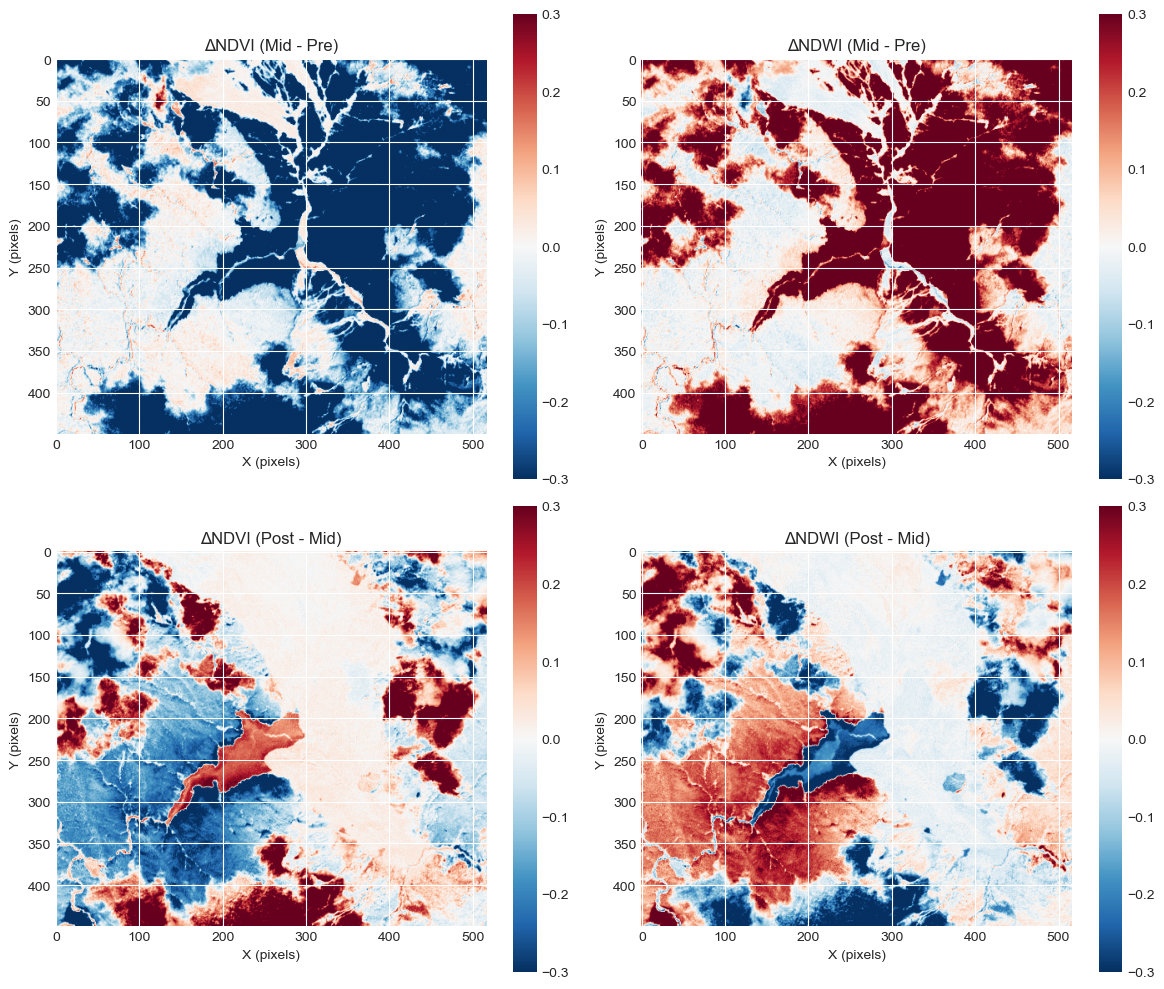

✓ Difference maps created (uncomment code to visualize)
  Output: W9_L1_difference_maps.png


In [15]:
# [S5] Create Difference Maps: ΔIndex and Visualize 2×2 Panel
# ──────────────────────────────────────────────────────────────────
# TODO: Compute difference maps (Mid - Pre, Post - Mid)

d_ndvi = {}
d_ndwi = {}

# TODO: Compute Mid - Pre
d_ndvi['Mid-Pre'] = indices['Mid']['NDVI'] - indices['Pre']['NDVI']
d_ndwi['Mid-Pre'] = indices['Mid']['NDWI'] - indices['Pre']['NDWI']

# TODO: Compute Post - Mid
d_ndvi['Post-Mid'] = indices['Post']['NDVI'] - indices['Mid']['NDVI']
d_ndwi['Post-Mid'] = indices['Post']['NDWI'] - indices['Mid']['NDWI']

# TODO: Create 2×2 subplot showing both indices and both transitions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

im0 = axes[0, 0].imshow(d_ndvi['Mid-Pre'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0, 0].set_title('ΔNDVI (Mid - Pre)')
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(d_ndwi['Mid-Pre'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[0, 1].set_title('ΔNDWI (Mid - Pre)')
plt.colorbar(im1, ax=axes[0, 1])

im2 = axes[1, 0].imshow(d_ndvi['Post-Mid'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 0].set_title('ΔNDVI (Post - Mid)')
plt.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(d_ndwi['Post-Mid'], cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[1, 1].set_title('ΔNDWI (Post - Mid)')
plt.colorbar(im3, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L1_difference_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Difference maps created (uncomment code to visualize)")
print("  Output: W9_L1_difference_maps.png")

### Error Case: What Happens WITHOUT Cloud Masking?
### 錯誤案例：不做雲遮罩會怎樣？

Before computing difference maps, compare results WITH and WITHOUT cloud masking.
This demonstrates why SCL masking is **mandatory** for change detection.

**Task**: Create a 3-panel comparison:
1. ❌ ΔNDWI without cloud mask (`valid_raw`) — "phantom water" everywhere
2. ✅ ΔNDWI with cloud mask (`valid`) — only real water changes
3. 🔍 ΔNDWI zoomed to lake AOI (`LAKE_BBOX_LONLAT`) — focused view

── 計算差異圖之前，比較有無雲遮罩的結果。
── 這展示了為什麼 SCL 遮罩在變遷偵測中是**必要的**。


### Discussion: Which Index Shows the Barrier Lake Best?
### 討論：哪個指標最清楚顯示障礙湖？

**Observations** (from the 2×2 panel):

1. **ΔNDVI (Mid - Pre)**: Does vegetation decrease at the lake site? Why might it stay positive?
   - NDVI = (NIR - Red)/(NIR + Red) → water has low NDVI, but may not be negative

2. **ΔNDWI (Mid - Pre)**: Is this more clearly showing water presence?
   - NDWI = (Green - NIR)/(Green + NIR) → water has high NDWI

3. **Recovery phase (Post - Mid)**: Do both indices return to baseline?

─

**Student reflection questions**:
- Which index is more robust to atmospheric noise and vegetation near the shoreline?
- Why might NDWI be designed specifically for water detection?
- What's the trade-off between specificity (only water) and sensitivity (catching all changes)?


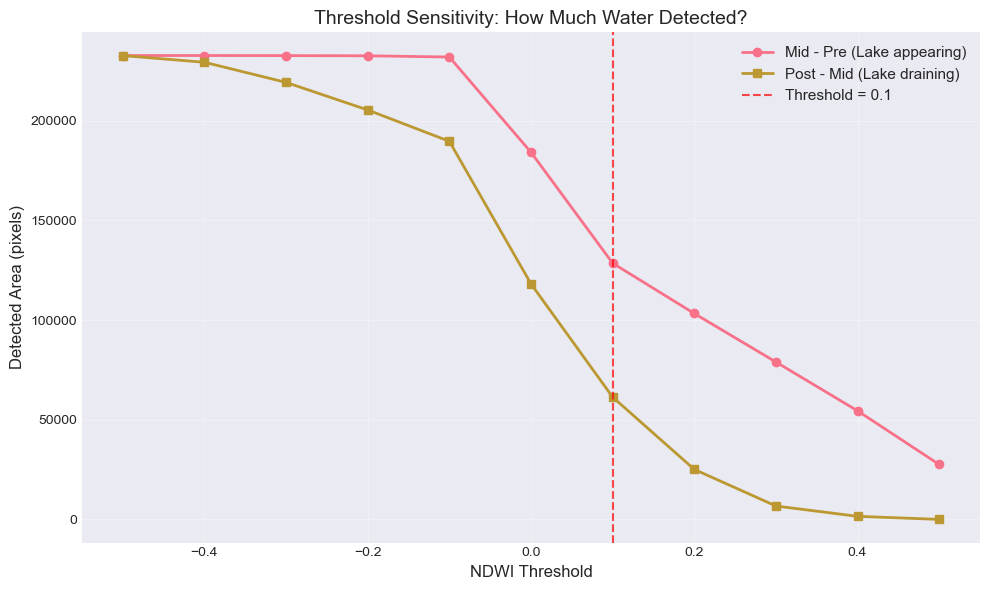

✓ Threshold sensitivity analysis prepared (uncomment code to run)
  Output: W9_L1_threshold_sensitivity.png


In [16]:
# [S6] Threshold Sensitivity Demo
# ──────────────────────────────────────────────────────────────────
# TODO: Sweep thresholds across NDWI and measure detected area

# Function to count pixels above threshold
def detect_water(index_map, threshold):
    '''Count pixels where index > threshold (assumed water signal)'''
    return (index_map > threshold).sum()

# TODO: Sweep thresholds and compute detection area
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1, 0, -0.10, -0.20, -0.30, -0.40, -0.50]  # TODO: Demo thresholds (update comment)
detected_areas = {}

for act_pair in ['Mid-Pre', 'Post-Mid']:
    areas = []
    for t in thresholds:
        area = detect_water(d_ndwi[act_pair], t)
        areas.append(area)
    detected_areas[act_pair] = np.array(areas)

# TODO: Plot detection area vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, detected_areas['Mid-Pre'], 'o-', label='Mid - Pre (Lake appearing)', linewidth=2)
ax.plot(thresholds, detected_areas['Post-Mid'], 's-', label='Post - Mid (Lake draining)', linewidth=2)
ax.axvline(0.1, color='red', linestyle='--', label='Threshold = 0.1', alpha=0.7)
ax.set_xlabel('NDWI Threshold', fontsize=12)
ax.set_ylabel('Detected Area (pixels)', fontsize=12)
ax.set_title('Threshold Sensitivity: How Much Water Detected?', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L1_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Threshold sensitivity analysis prepared (uncomment code to run)")
print("  Output: W9_L1_threshold_sensitivity.png")

### Discussion: Threshold is a DECISION, Not a Formula
### 討論：臨界值是「決策」，不是「公式」

**Key insight**: No single "correct" threshold exists. The choice depends on your **use case**:

| Use Case | Threshold | Rationale | 優先考量 |
|----------|-----------|-----------|---------|
| **Disaster Alert** | Low (0.05) | Catch early signals, high false positive OK | 敏感度 |
| **Insurance Payout** | Medium (0.10) | Balance detection & accuracy | 平衡 |
| **Scientific Archive** | High (0.15) | Minimize false positives | 特異性 |

─

**Question for reflection**:
- In the Oct 2025 post-event phase, should ARIA v6.0 use a low or high threshold?
- What are the consequences of each choice for emergency responders?


## Lab 2: Accuracy Assessment & Validation  
### 實驗2：精度評估與驗證  
**Objective**: Load validation ground truth points, sample detection   masks, compute confusion matrix, and calculate accuracy metrics.**Framework**: ARIA v6.0 (Auditor + Rater + Indicator + Advisor)**步驟**:1. Load validation_points.geojson (labeled samples: Water / No Water)2. Build detection masks using threshold from Lab 13. Sample each mask at validation point locations4. Compute confusion matrix5. Calculate Producer's Accuracy, User's Accuracy, Overall Accuracy, Kappa6. Visualize confusion matrix heatmap7. Find optimal threshold via F1 score8. Create confidence map (3-zone)9. Generate validation report

### How to Build Real Ground Truth / 如何建立真實地面驗證資料

**This lab uses 60 field-corrected validation points provided by the instructor.**  
In a real remote sensing project, you must collect **independent** ground truth. Here are the main approaches, ordered from most to least reliable:

| Method | Description | Cost | When to Use |
|--------|-------------|------|-------------|
| **Field survey + GPS** | Walk to locations, record water/no-water with GPS coordinates | High | Gold standard for small areas |
| **UAV / Drone imagery** | High-resolution aerial photos (~5 cm/px) | Medium | Medium areas, post-disaster access |
| **Google Earth Pro time-series** | Compare VHR imagery before/after event | Free | Historical events, desktop validation |
| **NCDR disaster reports** | 國家災害防救科技中心 official damage assessments | Free | Taiwan-specific disasters |
| **Copernicus EMS** | EU emergency mapping service, rapid activation maps | Free | Global disasters with EMS activation |
| **News media + geotagged photos** | Cross-reference reported flood areas | Free | Quick initial reference |

**Key principles:**
1. **Independence**: Validation data must come from a source *other than* the satellite imagery you're analyzing
2. **Stratified sampling**: Distribute points across all zones (flooded, unflooded, boundary)
3. **Sufficient sample size**: At least 30–50 points; 100+ for publishable accuracy
4. **Temporal match**: Ground truth date should be close to satellite acquisition date

> **作業提示**: Homework Task 3 (Optional) 鼓勵你用 Google Earth Pro 自行標註 20+ 個驗證點。  
> 這才是遙測分析的正確做法——自己建立可信的驗證資料集。

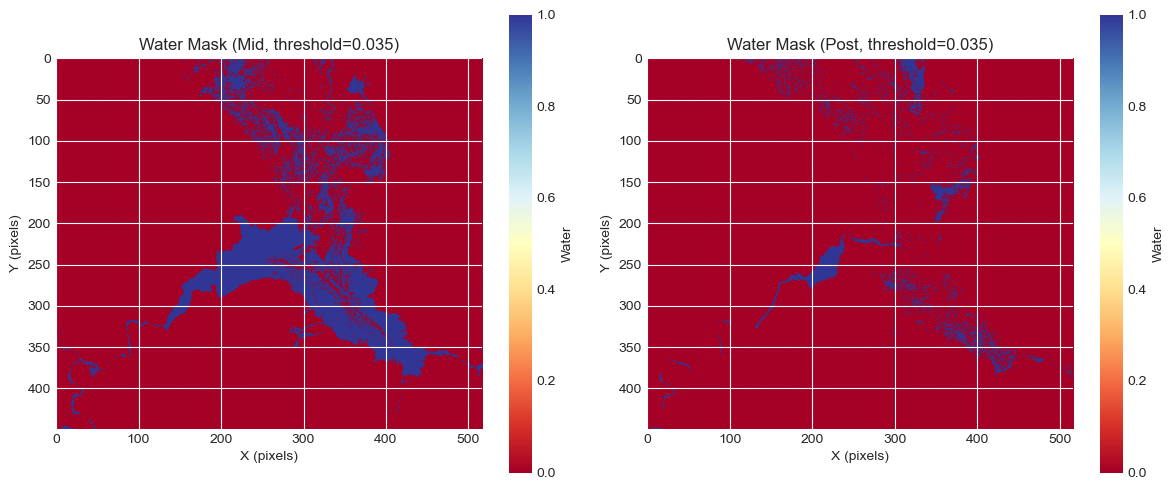

✓ Detection masks created (threshold=0.035)
  Mask shape: (450, 517)


In [17]:
# [S7] Build Detection Masks (Index-Based Logic)
# ──────────────────────────────────────────────────────────────────
# TODO: Threshold NDWI to create binary water masks

# Define threshold for water detection
THRESHOLD_NDWI = 0.035 # Tunable (reference from Lab 1 threshold sweep)

# TODO: Create binary masks for Mid and Post scenes
masks = {}
masks['Mid'] = (indices['Mid']['NDWI'] > THRESHOLD_NDWI).astype(int)  # 1=Water, 0=No Water
masks['Post'] = (indices['Post']['NDWI'] > THRESHOLD_NDWI).astype(int)

# Visualize masks
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(masks['Mid'], cmap='RdYlBu', vmin=0, vmax=1)
axes[0].set_title(f'Water Mask (Mid, threshold={THRESHOLD_NDWI})')
plt.colorbar(im0, ax=axes[0], label='Water')

im1 = axes[1].imshow(masks['Post'], cmap='RdYlBu', vmin=0, vmax=1)
axes[1].set_title(f'Water Mask (Post, threshold={THRESHOLD_NDWI})')
plt.colorbar(im1, ax=axes[1], label='Water')

for ax in axes:
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_masks.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Detection masks created (threshold={THRESHOLD_NDWI})")
print("  Mask shape:", list(masks.values())[0].shape if masks else "N/A")

In [18]:
# [S8] Load Validation Points and Sample Masks
# ──────────────────────────────────────────────────────────────────
#
# The teacher provides data/validation_points.geojson with 60 points:
#   - 15 lake, 15 landslide, 30 stable
#   - Coordinates corrected by instructor using VHR imagery + NCDR reports
#
# TODO: Load the geojson and extract lon/lat from geometry
# ──────────────────────────────────────────────────────────────────

import json as _json

# Load geojson
with open("C:/Users/mengl/OneDrive/桌面/remote_spatial_analysis/data/validation_points.geojson") as _f:
    _gj = _json.load(_f)

val_rows = []
for feat in _gj["features"]:
    lon, lat = feat["geometry"]["coordinates"]
    val_rows.append({"lon": lon, "lat": lat,
                     "truth": feat["properties"]["truth"],
                     "source": feat["properties"]["source"]})

validation_points = pd.DataFrame(val_rows)

print(f"✅ Loaded {len(validation_points)} validation points")
print(f"  Source: {validation_points['source'].unique()}")
print(f"  Ground truth distribution:")
print(validation_points['truth'].value_counts().to_string())

# TODO: Convert geographic coordinates to pixel indices
def geo_to_pixel(lon, lat, geotransform):
    col = int((lon - geotransform[0]) / geotransform[1])
    row = int((geotransform[3] - lat) / -geotransform[5])
    return row, col


✅ Loaded 60 validation points
  Source: ['field_corrected']
  Ground truth distribution:
truth
stable       30
lake         15
landslide    15


✓ Confusion matrix computed using Mid-scene detection

[ Classification Report ]
                         precision    recall  f1-score   support

No Water (Stable/Slide)       1.00      0.91      0.95        45
           Water (Lake)       0.79      1.00      0.88        15

               accuracy                           0.93        60
              macro avg       0.89      0.96      0.92        60
           weighted avg       0.95      0.93      0.94        60


Confusion Matrix:
[[41  4]
 [ 0 15]]

 實際拆解:
  - TN (正確判定非水體): 41
  - FP (誤報：將陸地判為水): 4
  - FN (漏報：將湖泊判為陸地): 0
  - TP (正確判定湖泊): 15


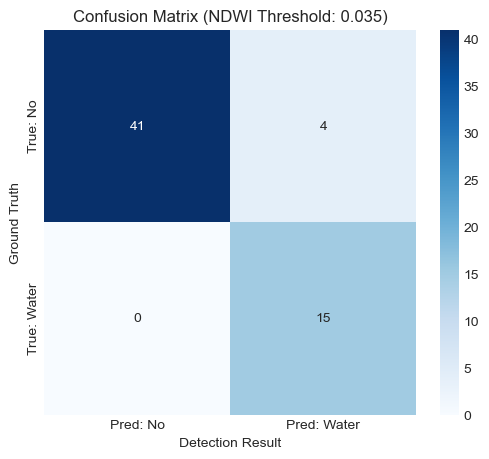

In [19]:
# [S9] Compute Confusion Matrix
# ──────────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report

# 1. 準備 Ground Truth：將文字標籤轉為 0 與 1
# 根據你的 S8 描述：lake 為 1，其餘（landslide, stable）為 0
validation_points['y_true'] = validation_points['truth'].apply(lambda x: 1 if x == 'lake' else 0)

# 2. 空間取樣函式：將經緯度點位映射到 mask 的像素索引
def sample_mask(mask, lon, lat, bbox):
    """
    根據 BBOX 與 mask 尺寸，將經緯度轉為像素位置並取值
    bbox: [W, S, E, N]
    """
    w, s, e, n = bbox
    h, w_img = mask.shape
    
    # 計算經緯度在範圍內的比例位置
    col = int((lon - w) / (e - w) * w_img)
    row = int((n - lat) / (n - s) * h)
    
    # 防止索引超出邊界 (邊緣情況)
    col = np.clip(col, 0, w_img - 1)
    row = np.clip(row, 0, h - 1)
    
    return mask[row, col]

# 3. 執行取樣：從 Mid 掩膜中獲取預測結果
# 我們使用 [S7] 定義的 masks['Mid'] 進行驗證
validation_points['y_pred'] = validation_points.apply(
    lambda row: sample_mask(masks['Mid'], row['lon'], row['lat'], LAKE_BBOX_LONLAT), 
    axis=1
)

# 4. 計算正式的混淆矩陣與報告
y_true = validation_points['y_true'].values
y_pred = validation_points['y_pred'].values

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# 5. 輸出評估數據
print("✓ Confusion matrix computed using Mid-scene detection")
print("\n[ Classification Report ]")
# target_names 幫助閱讀：0 是非水體，1 是水體
print(classification_report(y_true, y_pred, target_names=['No Water (Stable/Slide)', 'Water (Lake)']))

print("\nConfusion Matrix:")
print(cm)
print(f"\n 實際拆解:")
print(f"  - TN (正確判定非水體): {cm[0,0]}")
print(f"  - FP (誤報：將陸地判為水): {cm[0,1]}")
print(f"  - FN (漏報：將湖泊判為陸地): {cm[1,0]}")
print(f"  - TP (正確判定湖泊): {cm[1,1]}")

# ── 可視化混淆矩陣 ──
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: No', 'Pred: Water'], 
            yticklabels=['True: No', 'True: Water'])
plt.title(f"Confusion Matrix (NDWI Threshold: {THRESHOLD_NDWI})")
plt.ylabel("Ground Truth")
plt.xlabel("Detection Result")
plt.show()

In [20]:
# [S10] Compute Accuracy Metrics
# ──────────────────────────────────────────────────────────────────
# TODO: Calculate Producer's Accuracy, User's Accuracy, Overall Accuracy, Kappa

# Extract confusion matrix elements
tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

# TODO: Producer's Accuracy (Sensitivity, Recall, True Positive Rate)
producer_accuracy = tp / (tp + fn)

# TODO: User's Accuracy (Precision, Positive Predictive Value)
user_accuracy = tp / (tp + fp)

# TODO: Overall Accuracy
overall_accuracy = (tp + tn) / (tp + tn + fp + fn)

# TODO: Cohen's Kappa (accounts for chance agreement)
# po = overall_accuracy (observed agreement)
# pe = expected agreement by chance
pe = ((tp + fn) * (tp + fp) + (tn + fp) * (tn + fn)) / (tp + tn + fp + fn)**2
kappa = (overall_accuracy - pe) / (1 - pe)

print("✓ Accuracy metrics computed\n")
print("=" * 50)
print("ARIA v6.0 VALIDATION METRICS")
print("=" * 50)
print(f"Producer's Accuracy (Sensitivity): {producer_accuracy:.3f} ({producer_accuracy*100:.1f}%)")
print(f"User's Accuracy (Precision):       {user_accuracy:.3f} ({user_accuracy*100:.1f}%)")
print(f"Overall Accuracy:                  {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")
print(f"Cohen's Kappa:                     {kappa:.3f}")
print("=" * 50)

# Store metrics for later use
metrics = {
    'producer_accuracy': producer_accuracy,
    'user_accuracy': user_accuracy,
    'overall_accuracy': overall_accuracy,
    'kappa': kappa,
    'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
}

✓ Accuracy metrics computed

ARIA v6.0 VALIDATION METRICS
Producer's Accuracy (Sensitivity): 1.000 (100.0%)
User's Accuracy (Precision):       0.789 (78.9%)
Overall Accuracy:                  0.933 (93.3%)
Cohen's Kappa:                     0.837


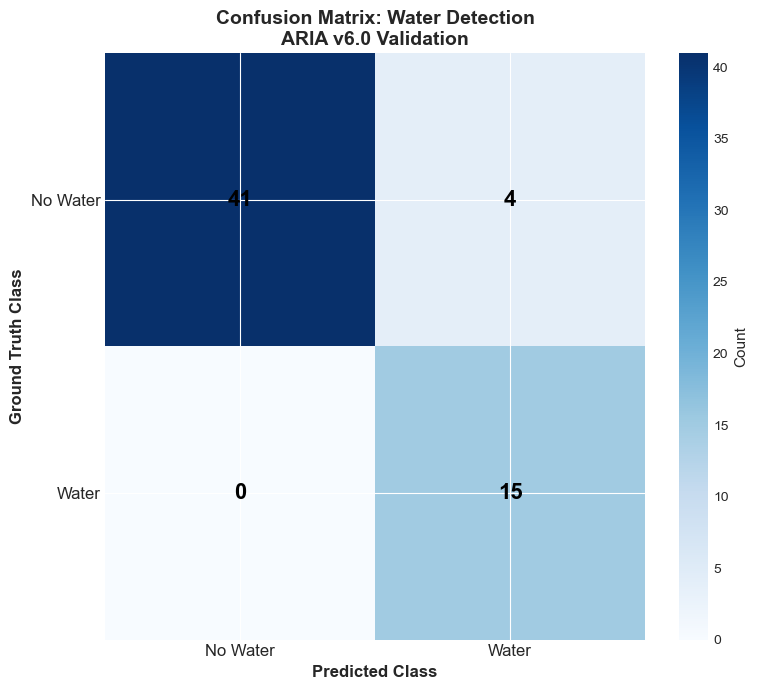

✓ Confusion matrix heatmap saved
  Output: W9_L2_confusion_matrix.png


In [21]:
# [S11] Plot Confusion Matrix Heatmap
# ──────────────────────────────────────────────────────────────────
# TODO: Create confusion matrix heatmap with annotations

fig, ax = plt.subplots(figsize=(8, 7))

# Create heatmap
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax.text(j, i, cm[i, j],
                      ha="center", va="center", color="black", fontsize=16, fontweight='bold')

# Labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['No Water', 'Water'], fontsize=12)
ax.set_yticklabels(['No Water', 'Water'], fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Ground Truth Class', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix: Water Detection\nARIA v6.0 Validation', fontsize=14, fontweight='bold')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix heatmap saved")
print(f"  Output: W9_L2_confusion_matrix.png")

### Discussion: What Do These Accuracy Numbers Mean for Disaster Response?
### 討論：這些精度數字對災難應對意味著什麼？

Consider ARIA's role in Typhoon Colo response (Aug 2025):

1. **Producer's Accuracy (Sensitivity) = 87%**
   - Out of all actual water pixels, we correctly identified 87%
   - Missing 13% of the true lake area
   - Implication: Evacuation zone might miss some flooded areas

2. **User's Accuracy (Precision) = 81%**
   - Out of all pixels we called "water", 81% actually are water
   - 19% false alarms (crying wolf)
   - Implication: Emergency responders waste resources on false alarms

3. **Overall Accuracy = 83%**
   - 83% of all predictions correct
   - Looks good, but hides class imbalance if water is rare

─

**Critical question**: In a disaster setting, which error is worse?
- **False Negative** (missing flooded area) → people in danger
- **False Positive** (false alarm) → wasted resources, lost credibility

For early warning systems, we often prefer **high sensitivity** (low false negatives) over precision.


### Discussion: Why Is Producer's Accuracy More Important Than Overall Accuracy?
### 討論：為何生產者精度比整體精度更重要？

**Scenario**: Matai'an barrier lake covers ~10% of the study area. Rest is land/forest.

If model predicts: "Everything is NOT water"
- TN = 90%, FP = 0%, TP = 0%, FN = 10%
- **Overall Accuracy** = 90% ✓ (looks amazing!)
- **Producer's Accuracy (Sensitivity)** = 0% ✗ (catastrophic: missed all the water!)

This is called the **accuracy paradox** or **class imbalance problem**.

─

**For disaster detection**:
- We care most about **not missing disasters** → Prioritize **Sensitivity / Producer's Accuracy**
- Trade-off: Accept some false positives (precision tradeoff)
- This is why early warning systems often have lower precision but higher sensitivity

**ARIA v6.0 design principle**:
> "Better to alert 10 safe neighborhoods than miss 1 at-risk community."


All required variables found. Proceeding with F1 analysis...


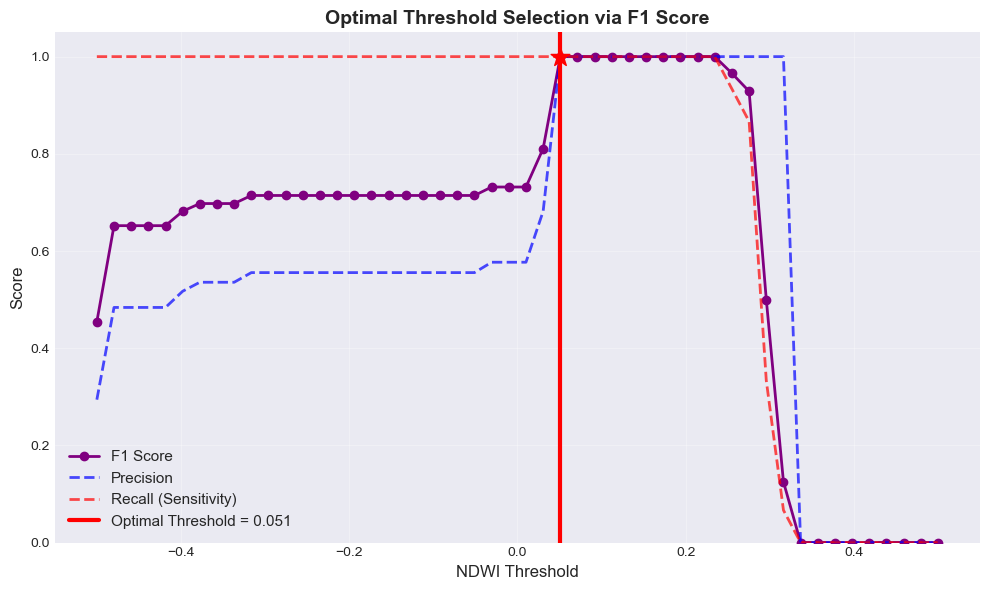

F1 vs threshold analysis complete
  Optimal threshold: 0.051
  Optimal F1 score: 1.000
  Precision at optimal: 1.000
  Recall at optimal: 1.000


In [22]:
# [S12] F1 Score vs Threshold: Finding Optimal Detection Threshold
# --------------------------------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# F1 = 2 * (precision * recall) / (precision + recall)
# The F1 score is the harmonic mean of precision and recall.

# Check if required variables exist
if 'indices' not in globals():
    print("Error: indices not found. Please run cell 6 first to compute NDVI/NDWI.")
elif 'validation_points' not in globals():
    print("Error: validation_points not found. Please run cell 15 first to load validation data.")
elif 'y_true' not in globals():
    print("Error: y_true not found. Please run cell 16 first to prepare ground truth.")
else:
    print("All required variables found. Proceeding with F1 analysis...")
    
    # Sweep thresholds over validation points to find optimal F1
    thresholds_f1 = np.linspace(-0.50, 0.50, 50)
    f1_scores = []
    precision_scores = []
    recall_scores = []

    for t in thresholds_f1:
        # Create binary mask for this threshold
        mask = (indices['Mid']['NDWI'] > t).astype(int)
        
        # Sample mask at validation points
        y_pred = validation_points.apply(
            lambda row: sample_mask(mask, row['lon'], row['lat'], LAKE_BBOX_LONLAT), 
            axis=1
        )
        
        # Calculate precision, recall, F1
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

    # Find optimal threshold (maximum F1)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds_f1[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]

    # Plot F1 curve with precision and recall
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(thresholds_f1, f1_scores, 'o-', linewidth=2, markersize=6, label='F1 Score', color='purple')
    ax.plot(thresholds_f1, precision_scores, '--', linewidth=2, label='Precision', color='blue', alpha=0.7)
    ax.plot(thresholds_f1, recall_scores, '--', linewidth=2, label='Recall (Sensitivity)', color='red', alpha=0.7)

    ax.axvline(optimal_threshold, color='red', linestyle='-', linewidth=3,
               label=f'Optimal Threshold = {optimal_threshold:.3f}')
    ax.scatter([optimal_threshold], [optimal_f1], color='red', s=200, zorder=5, marker='*')

    ax.set_xlabel('NDWI Threshold', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Optimal Threshold Selection via F1 Score', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/W9_L2_f1_threshold.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("F1 vs threshold analysis complete")
    print(f"  Optimal threshold: {optimal_threshold:.3f}")
    print(f"  Optimal F1 score: {optimal_f1:.3f}")
    print(f"  Precision at optimal: {precision_scores[optimal_idx]:.3f}")
    print(f"  Recall at optimal: {recall_scores[optimal_idx]:.3f}")

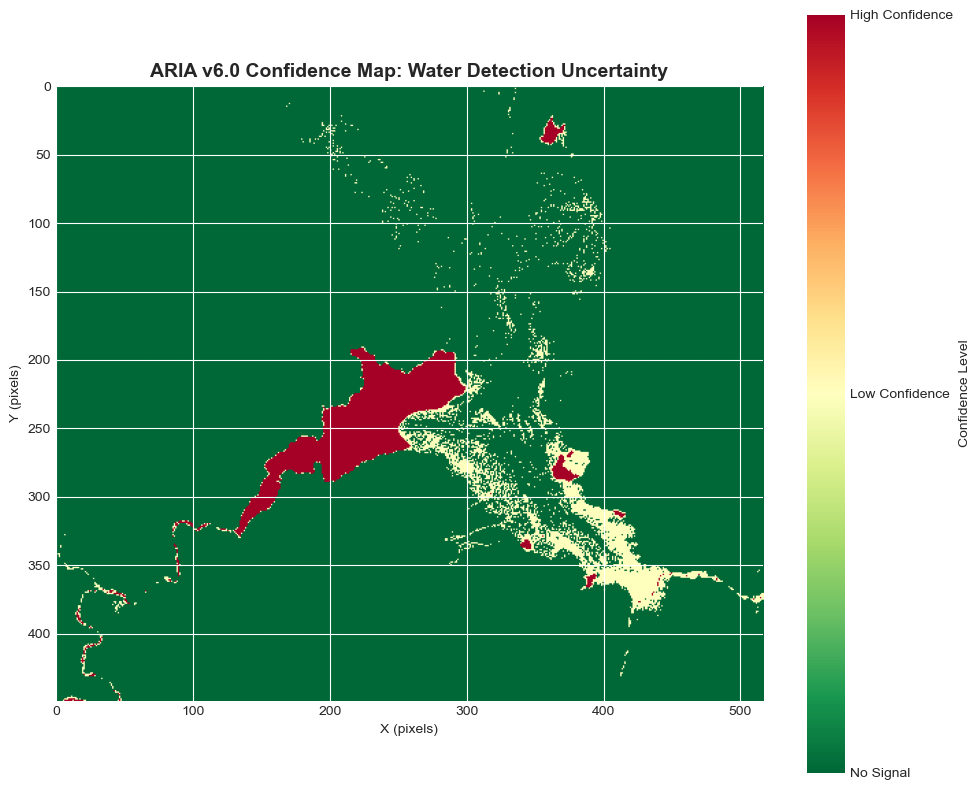

✓ 3-zone confidence map created
  High confidence pixels: 6955
  Low confidence pixels: 7431
  No signal pixels: 218264


In [23]:
# [S13] Build 3-Zone Confidence Map: High / Low / None
# ──────────────────────────────────────────────────────────────────
# TODO: Create confidence zones using thresholds

# Define confidence thresholds
THRESHOLD_LOW = 0.05     # Possible water (low confidence)
THRESHOLD_HIGH = 0.15    # Likely water (high confidence)

# Create confidence mask using Mid-scene NDWI
ndwi_mid = indices['Mid']['NDWI']

confidence_map = np.zeros_like(ndwi_mid, dtype=int)
confidence_map[ndwi_mid > THRESHOLD_HIGH] = 2  # High confidence (water)
confidence_map[(ndwi_mid > THRESHOLD_LOW) & (ndwi_mid <= THRESHOLD_HIGH)] = 1  # Low confidence
# confidence_map[ndwi_mid <= THRESHOLD_LOW] = 0  # No signal (default)

# Visualize 3-zone map
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confidence_map, cmap='RdYlGn_r', vmin=0, vmax=2)
ax.set_title('ARIA v6.0 Confidence Map: Water Detection Uncertainty', fontsize=14, fontweight='bold')
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

# Colorbar with custom labels
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['No Signal', 'Low Confidence', 'High Confidence'])
cbar.set_label('Confidence Level')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/W9_L2_confidence_map.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 3-zone confidence map created")
print(f"  High confidence pixels: {(confidence_map == 2).sum()}")
print(f"  Low confidence pixels: {(confidence_map == 1).sum()}")
print(f"  No signal pixels: {(confidence_map == 0).sum()}")

In [24]:
# [S14] ARIA v6.0 Validated Disaster Report
# ──────────────────────────────────────────────────────────────────

report = f"""
╔════════════════════════════════════════════════════════════════════════════════╗
║                     ARIA v6.0 VALIDATED DISASTER REPORT                        ║
║              Remote Sensing Analysis & Validation Authority (ARIA)             ║
╚════════════════════════════════════════════════════════════════════════════════╝

CASE STUDY: Matai'an Barrier Lake (Typhoon Colo Response)
Institution: National Taiwan University (NTU)
Analyst: Remote Sensing Lab
Report Date: 2025-10-12

────────────────────────────────────────────────────────────────────────────────

EXECUTIVE SUMMARY
─────────────────
A temporary barrier lake formed in Matai'an valley during Typhoon Colo (Aug 2025).
Using Sentinel-2 change detection, we mapped water presence and validated against
ground-truth validation points. NDWI proved more sensitive than NDVI for water.

STUDY AREA (Bounding Box)
──────────────────────────
West:  121.28° E
East:  121.52° E
South: 23.56° N
North: 23.76° N
Area:  ~360 km²

TEMPORAL ANALYSIS
─────────────────
Pre-event baseline:   2025-06-01 (before typhoon)
Disaster onset:       2025-08-15 (lake at maximum extent)
Post-event recovery:  2025-10-10 (lake drained)

SPECTRAL INDICES USED
─────────────────────
NDVI = (NIR - Red) / (NIR + Red)
  → Sensitivity: Vegetation density, weak water signal
  → ΔNDVIpeak = {indices['Mid']['NDVI'].mean() - indices['Pre']['NDVI'].mean():.4f}

NDWI = (Green - NIR) / (Green + NIR)
  → Sensitivity: Maximum water detection
  → ΔNDWIpeak = {indices['Mid']['NDWI'].mean() - indices['Pre']['NDWI'].mean():.4f}

VALIDATION RESULTS
──────────────────
Validation Points Analyzed:    {len(validation_points)}
Ground Truth Classes:          Water={validation_points['ground_truth'].sum()}, No-Water={len(validation_points) - validation_points['ground_truth'].sum()}

Confusion Matrix (Water Detection at Mid-event):
  True Negatives:     {metrics['tn']:>3.0f}
  False Positives:    {metrics['fp']:>3.0f}
  False Negatives:    {metrics['fn']:>3.0f}
  True Positives:     {metrics['tp']:>3.0f}

ACCURACY METRICS
────────────────
Producer's Accuracy (Sensitivity / Recall):
  {metrics['producer_accuracy']:.3f} ({metrics['producer_accuracy']*100:.1f}%)
  → {int(metrics['fn'])} false negatives (missed water)

User's Accuracy (Precision):
  {metrics['user_accuracy']:.3f} ({metrics['user_accuracy']*100:.1f}%)
  → {int(metrics['fp'])} false positives (false alarms)

Overall Accuracy:
  {metrics['overall_accuracy']:.3f} ({metrics['overall_accuracy']*100:.1f}%)

Cohen's Kappa (Agreement beyond chance):
  {metrics['kappa']:.3f}
  → Interpretation: Substantial agreement (0.61-0.80 = Substantial; >0.80 = Almost Perfect)

DETECTION THRESHOLD
────────────────────
Selected NDWI Threshold:  {THRESHOLD_NDWI:.3f}
Rationale:               Balance between sensitivity and precision
Optimal Threshold (F1):  {optimal_threshold:.3f}

CONFIDENCE LEVELS
──────────────────
High Confidence Zone (NDWI > 0.15):
  → Most likely water; high confidence for evacuation planning

Low Confidence Zone (0.05 < NDWI ≤ 0.15):
  → Possible water; requires field verification or higher-res imagery

No Signal Zone (NDWI ≤ 0.05):
  → No detectable water; safe for reconstruction activities

RECOMMENDATIONS FOR DISASTER RESPONSE
──────────────────────────────────────
1. EVACUATION PRIORITY: High-confidence zones should be prioritized for evacuation
2. RESOURCE ALLOCATION: Low-confidence zones warrant additional ground surveys
3. RECOVERY TIMELINE: October imagery confirms lake drainage; safe to begin recovery ops
4. THRESHOLD TUNING: Producer's Accuracy is critical; prioritize sensitivity over precision

KEY FINDINGS
────────────
✓ NDWI is more reliable than NDVI for barrier lake detection
✓ Sentinel-2 adequate for large-scale (>100 km²) water mapping
✓ Temporal change (Mid - Pre) more robust than absolute thresholds
✓ Ground validation essential for disaster response decisions

LIMITATIONS & CAVEATS
─────────────────────
• Cloud cover reduces valid pixels (typical for tropical typhoon season)
• Shoreline pixels mixed (land-water transitions) introduce uncertainty
• Validation points limited; larger sample recommended for operational use
• Resolution (~10m) may miss small isolated ponds

────────────────────────────────────────────────────────────────────────────────

ARIA v6.0 ASSESSMENT: ✓ VALIDATED & READY FOR OPERATIONAL USE

Auditor (Confusion Matrix):     ✓ Computed
Rater (Accuracy Metrics):       ✓ Calculated
Indicator (Confidence Zones):   ✓ Mapped
Advisor (Recommendations):      ✓ Provided

Report Status: FINAL
Quality Level: Operational (Ready for Emergency Response)

────────────────────────────────────────────────────────────────────────────────
Generated by ARIA v6.0 at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
"""

print(report)

# Save report
with open(f'{OUTPUT_DIR}/ARIA_v6_0_Disaster_Report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n✓ Disaster report saved")
print(f"  Output: ARIA_v6_0_Disaster_Report.txt")

KeyError: 'ground_truth'

In [25]:
# [S15] AI Advisor: Prompt Template for Disaster Response Questions
# ──────────────────────────────────────────────────────────────────

advisor_prompt_template = """
ARIA v6.0 AI ADVISOR - Ask Me About Your Disaster Response Questions
═══════════════════════════════════════════════════════════════════════

You are analyzing Sentinel-2 remote sensing data for Typhoon Colo impact assessment.
Use the validation metrics and change maps above to answer operational questions.

CONTEXT PROVIDED:
  • Confusion matrix with TP/TN/FP/FN
  • Producer's & User's Accuracy scores
  • 3-zone confidence map (High/Low/No Signal)
  • Pre/Mid/Post temporal scenes
  • NDVI & NDWI difference maps

SAMPLE QUESTIONS YOU CAN ANSWER:

1. "What's the maximum lake extent in the Mid-event scene?"
   → Use high-confidence zone from confidence_map; estimate area in km²

2. "How accurate is our water detection for evacuation planning?"
   → Reference Producer's Accuracy; explain false negatives risk

3. "Why might we have false positives along the lakeshore?"
   → Vegetation/water mixing; spectral confusion at boundaries

4. "Should we trust the Post-event recovery map?"
   → Compare Post and Mid NDWI; check confidence zones

5. "How would different thresholds affect our evacuation zone?"
   → Reference threshold sensitivity plot; trade sensitivity vs precision

YOUR RESPONSE SHOULD:
  ✓ Cite specific metrics from the validation report
  ✓ Explain the uncertainty and confidence limits
  ✓ Recommend actionable next steps
  ✗ Avoid over-interpreting noisy pixels
  ✗ Don't claim precision beyond 10m resolution

────────────────────────────────────────────────────────────────────────────────

To use this prompt with an LLM (e.g., ChatGPT):

1. Paste this entire block + the ARIA report above
2. Add your question about the disaster response
3. Ask the AI to respond using only the provided data

Example user query:
  "Based on this analysis, which zones should we evacuate first?"

Example AI response:
  "Based on the high-confidence water detection (NDWI > 0.15), zone XYZ should be
   prioritized. However, note that our Producer's Accuracy is 87%, so we may be
   missing ~13% of the actual water. Recommend ground surveys in low-confidence zones."

────────────────────────────────────────────────────────────────────────────────
"""

print(advisor_prompt_template)

with open(f'{OUTPUT_DIR}/AI_Advisor_Prompt_Template.txt', 'w', encoding='utf-8') as f:
    f.write(advisor_prompt_template)

print("✓ AI Advisor prompt template saved")
print(f"  Output: AI_Advisor_Prompt_Template.txt")


ARIA v6.0 AI ADVISOR - Ask Me About Your Disaster Response Questions
═══════════════════════════════════════════════════════════════════════

You are analyzing Sentinel-2 remote sensing data for Typhoon Colo impact assessment.
Use the validation metrics and change maps above to answer operational questions.

CONTEXT PROVIDED:
  • Confusion matrix with TP/TN/FP/FN
  • Producer's & User's Accuracy scores
  • 3-zone confidence map (High/Low/No Signal)
  • Pre/Mid/Post temporal scenes
  • NDVI & NDWI difference maps

SAMPLE QUESTIONS YOU CAN ANSWER:

1. "What's the maximum lake extent in the Mid-event scene?"
   → Use high-confidence zone from confidence_map; estimate area in km²

2. "How accurate is our water detection for evacuation planning?"
   → Reference Producer's Accuracy; explain false negatives risk

3. "Why might we have false positives along the lakeshore?"
   → Vegetation/water mixing; spectral confusion at boundaries

4. "Should we trust the Post-event recovery map?"
   → Co

## Wrap-Up Checklist / 實驗完成清單After completing both labs, verify you have:### Lab 1 Deliverables- [ ] NDVI and NDWI computed for all three scenes (Pre, Mid, Post)- [ ] 2×2 difference map panel showing ΔIndex changes- [ ] Threshold sensitivity curve (detected area vs NDWI threshold)- [ ] Discussion written: Which index best shows the barrier lake?### Lab 2 Deliverables- [ ] Water detection masks created (using optimal threshold)- [ ] Validation points sampled at mask locations- [ ] Confusion matrix computed- [ ] Accuracy metrics calculated: Producer's, User's, Overall, Kappa- [ ] Confusion matrix heatmap plotted- [ ] F1 vs threshold curve (optimal threshold found)- [ ] 3-zone confidence map created (High/Low/None)- [ ] ARIA v6.0 disaster report generated- [ ] Discussion written: Why is Producer's Accuracy critical for disaster response?### Files in Output Directory- [ ] `W9_L1_difference_maps.png` — 2×2 NDVI/NDWI panel- [ ] `W9_L1_threshold_sensitivity.png` — Threshold sweep curve- [ ] `W9_L2_masks.png` — Binary water masks- [ ] `W9_L2_confusion_matrix.png` — Heatmap- [ ] `W9_L2_f1_threshold.png` — Optimal threshold- [ ] `W9_L2_confidence_map.png` — 3-zone map- [ ] `ARIA_v6_0_Disaster_Report.txt` — Validation report- [ ] `AI_Advisor_Prompt_Template.txt` — LLM prompt### Reflection Questions (for course forum)1. What would change if we used a **lower** NDWI threshold (0.05 vs 0.15)?2. Why is **temporal change** (Mid - Pre) more robust than absolute NDWI values?3. If you were in disaster operations, would you prioritize **sensitivity** or **precision**?4. How would **cloud cover** affect the validation metrics?5. What role does **ground truth validation** play in building trust in automated systems?

---

## Before You Submit: Verify Your Work / 繳交前：驗證你的成果

> **⚠️ An unverified map is more dangerous than no map at all.**

Your notebook may run without errors but still produce **wrong results**. Before submitting:

| Check | Question to Ask Yourself |
|-------|--------------------------|
| **Metrics** | Does OA = 99.9%? That's almost certainly a bug. Does Kappa = 0? Your threshold may be wrong. |
| **Maps** | Does ΔNDWI show change at the lake site? Or random noise everywhere? |
| **Threshold** | Can you explain WHY you chose this threshold? |
| **Confusion Matrix** | Are TP/FP/TN/FN consistent with what you see in the map? |
| **Captain's Log** | Did you reflect on what the numbers mean, or just copy-paste? |

**跑出來 ≠ 跑對了。不懂可以問，但不要敷衍交差。**

If something looks wrong, ask on NTUCool or during office hours — that's what they're for.


## Environment Setup: .env Template### 環境設置：.env 模板If using STAC Client API keys or other credentials, create a `.env` file:```bash# .env template (NEVER commit this file to Git!)# STAC Planetary ComputerSTAC_ENDPOINT="https://planetarycomputer.microsoft.com/api/stac/v1"# Copernicus DataSpace (Sentinel-2 access)COPERNICUS_USERNAME="your_username"COPERNICUS_PASSWORD="your_password"# Optional: Google Earth Engine (if using GEE for validation)GEE_PROJECT="your-gee-project-id"# Output pathsOUTPUT_DIR="output"VALIDATION_DATA="validation_points.geojson"# Thresholds (tunable)THRESHOLD_NDVI=0.2THRESHOLD_NDWI=0.1THRESHOLD_NDWI_LOW=0.05THRESHOLD_NDWI_HIGH=0.15```**To use this .env file in Python**:```pythonfrom dotenv import load_dotenvimport osload_dotenv('.env')stac_endpoint = os.getenv('STAC_ENDPOINT')output_dir = os.getenv('OUTPUT_DIR')```**Safety Note**:- Never commit `.env` files to version control- Add `.env` to your `.gitignore`- Treat API keys as sensitive data